# Inferential Statistics — Practical Notebook

This notebook accompanies the textbook-style README. It focuses only on sampling distributions, standard error, point estimation, confidence intervals, margin of error, sample-size calculations, and bootstrap resampling.

## 1. Learning Objectives

By the end of this notebook, you should be able to:

- distinguish parameters and statistics;
- calculate sample means and proportions;
- calculate standard errors;
- construct basic confidence intervals;
- understand the role of z and t critical values;
- calculate margin of error;
- determine basic sample sizes;
- simulate sampling distributions;
- understand bootstrap resampling.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

np.random.seed(42)

## 2. Sample Mean and Standard Error

We calculate a sample mean and estimate its standard error using $s/\sqrt{n}$.

In [2]:
data = np.array([62, 68, 71, 75, 77, 80, 83, 85])
n = len(data)
mean = data.mean()
s = data.std(ddof=1)
se = s / np.sqrt(n)

print('Sample mean:', mean)
print('Sample standard deviation:', s)
print('Standard error:', se)

Sample mean: 75.125
Sample standard deviation: 7.809106405802321
Standard error: 2.7609360472750644


## 3. Sampling Distribution Simulation

The following experiment repeatedly draws samples from a population and calculates their means. The resulting values approximate the sampling distribution of the sample mean.

In [3]:
population = np.random.normal(loc=70, scale=12, size=100000)
sample_size = 36
repetitions = 5000

sample_means = np.array([
    np.mean(np.random.choice(population, size=sample_size, replace=False))
    for _ in range(repetitions)
])

print('Population mean:', population.mean())
print('Mean of sample means:', sample_means.mean())
print('SD of sample means:', sample_means.std(ddof=1))
print('Theoretical SE:', 12 / np.sqrt(sample_size))

Population mean: 70.0116024176914
Mean of sample means: 70.00062494698513
SD of sample means: 1.992626899965951
Theoretical SE: 2.0


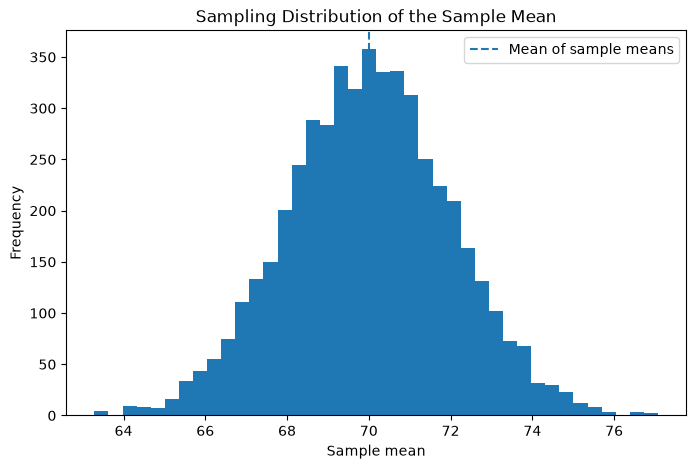

In [4]:
plt.figure(figsize=(8, 5))
plt.hist(sample_means, bins=40)
plt.axvline(sample_means.mean(), linestyle='--', label='Mean of sample means')
plt.xlabel('Sample mean')
plt.ylabel('Frequency')
plt.title('Sampling Distribution of the Sample Mean')
plt.legend()
plt.show()

## 4. Sample Proportion

Suppose 120 out of 200 observations have a particular characteristic.

In [5]:
x = 120
n = 200
p_hat = x / n
se_p = np.sqrt(p_hat * (1 - p_hat) / n)

print('Sample proportion:', p_hat)
print('Estimated standard error:', se_p)

Sample proportion: 0.6
Estimated standard error: 0.034641016151377546


## 5. Confidence Interval for a Mean Using the t-Distribution

When the population standard deviation is unknown, use the sample standard deviation and a t critical value.

In [6]:
xbar = 50
s = 8
n = 16
confidence = 0.95
alpha = 1 - confidence
df = n - 1

t_star = stats.t.ppf(1 - alpha / 2, df)
se = s / np.sqrt(n)
margin = t_star * se
lower = xbar - margin
upper = xbar + margin

print('t critical value:', t_star)
print('Standard error:', se)
print('Margin of error:', margin)
print('Confidence interval:', (lower, upper))

t critical value: 2.1314495455597755
Standard error: 2.0
Margin of error: 4.262899091119551
Confidence interval: (np.float64(45.73710090888045), np.float64(54.26289909111955))


## 6. Confidence Interval for a Proportion

In [7]:
x = 325
n = 500
p_hat = x / n
z_star = stats.norm.ppf(0.975)
se = np.sqrt(p_hat * (1 - p_hat) / n)
margin = z_star * se
ci = (p_hat - margin, p_hat + margin)

print('Sample proportion:', p_hat)
print('Standard error:', se)
print('Margin of error:', margin)
print('95% CI:', ci)

Sample proportion: 0.65
Standard error: 0.02133072900770154
Margin of error: 0.04180746061907883
95% CI: (np.float64(0.6081925393809212), np.float64(0.6918074606190788))


## 7. Confidence Level Comparison

The same point estimate can produce different interval widths at different confidence levels.

In [8]:
xbar = 72
s = 10
n = 100
df = n - 1
se = s / np.sqrt(n)

rows = []
for confidence in [0.90, 0.95, 0.99]:
    alpha = 1 - confidence
    critical = stats.t.ppf(1 - alpha / 2, df)
    margin = critical * se
    rows.append([confidence, critical, margin, xbar-margin, xbar+margin])

pd.DataFrame(rows, columns=['Confidence', 'Critical value', 'Margin of error', 'Lower', 'Upper'])

,Confidence,Critical value,Margin of error,Lower,Upper
0,0.90,1.660391,1.660391,70.339609,73.660391
1,0.95,1.984217,1.984217,70.015783,73.984217
2,0.99,2.626405,2.626405,69.373595,74.626405


## 8. Sample Size for a Mean

Use the planning formula $n=(z^*\sigma/E)^2$ and round upward.

In [9]:
sigma = 12
E = 2
z_star = stats.norm.ppf(0.975)

n_required = (z_star * sigma / E) ** 2
print('Unrounded sample size:', n_required)
print('Required sample size:', int(np.ceil(n_required)))

Unrounded sample size: 138.2925175449885
Required sample size: 139


## 9. Sample Size for a Proportion

When the population proportion is unknown, use $p=0.5$ for the conservative planning calculation.

In [10]:
E = 0.05
z_star = stats.norm.ppf(0.975)
p = 0.5

n_required = (z_star ** 2 * p * (1-p)) / (E ** 2)
print('Unrounded sample size:', n_required)
print('Required sample size:', int(np.ceil(n_required)))

Unrounded sample size: 384.14588206941244
Required sample size: 385


## 10. Bootstrap Resampling

Bootstrap sampling repeatedly draws observations with replacement from the observed sample. Here we estimate the bootstrap distribution of the sample mean.

In [11]:
sample = np.array([4, 5, 6, 7, 8])
B = 5000

bootstrap_means = np.array([
    np.mean(np.random.choice(sample, size=len(sample), replace=True))
    for _ in range(B)
])

print('Original sample mean:', sample.mean())
print('Bootstrap mean:', bootstrap_means.mean())
print('Bootstrap standard error:', bootstrap_means.std(ddof=1))

Original sample mean: 6.0
Bootstrap mean: 6.00444
Bootstrap standard error: 0.6281553965703456


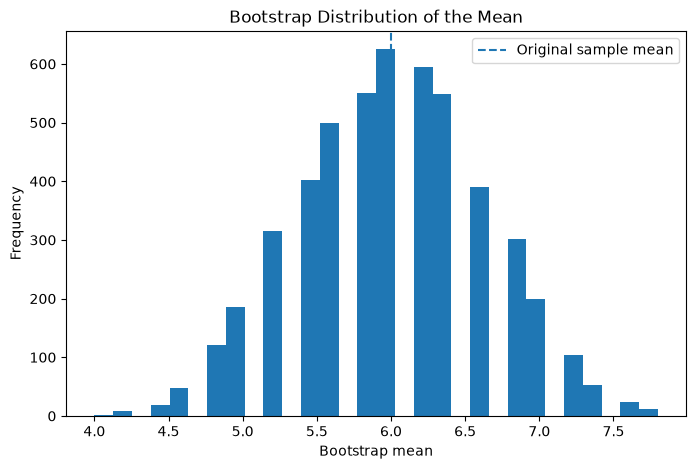

In [12]:
plt.figure(figsize=(8, 5))
plt.hist(bootstrap_means, bins=30)
plt.axvline(sample.mean(), linestyle='--', label='Original sample mean')
plt.xlabel('Bootstrap mean')
plt.ylabel('Frequency')
plt.title('Bootstrap Distribution of the Mean')
plt.legend()
plt.show()

## 11. Bootstrap Percentile Interval

For learning purposes, we can use bootstrap percentiles to form a simple 95% interval.

In [13]:
lower, upper = np.percentile(bootstrap_means, [2.5, 97.5])
print('Bootstrap percentile interval:', (lower, upper))

Bootstrap percentile interval: (np.float64(4.8), np.float64(7.2))


## 12. Difference Between Two Means

For two independent groups, the estimated difference is $\bar{x}_1-\bar{x}_2$. A common estimated standard error is $\sqrt{s_1^2/n_1+s_2^2/n_2}$.

In [14]:
x1, s1, n1 = 82, 10, 100
x2, s2, n2 = 78, 12, 144

estimate = x1 - x2
se_diff = np.sqrt(s1**2/n1 + s2**2/n2)
z_star = stats.norm.ppf(0.975)
margin = z_star * se_diff

print('Estimated difference:', estimate)
print('Standard error:', se_diff)
print('Approximate 95% CI:', (estimate-margin, estimate+margin))

Estimated difference: 4
Standard error: 1.4142135623730951
Approximate 95% CI: (np.float64(1.228192351300644), np.float64(6.771807648699356))


## 13. Practice Questions

1. A sample of 64 observations has mean 75 and standard deviation 16. Calculate the estimated standard error.
2. Explain why increasing sample size reduces the standard error.
3. Calculate a 95% confidence interval for a mean when $\bar{x}=50$, $s=8$, and $n=16$.
4. In a survey of 500 customers, 325 say yes. Calculate the sample proportion.
5. Calculate the 95% confidence interval for that proportion.
6. Why is $p=0.5$ used when planning a proportion sample size and the true proportion is unknown?
7. Explain the difference between a point estimate and an interval estimate.
8. Explain the difference between standard deviation and standard error.
9. What does an unbiased estimator mean?
10. What is the purpose of bootstrap resampling?

## 14. Final Checklist

Before using an inferential method, check the population/sample definition, sampling method, independence, relevant distributional conditions, parameter being estimated, standard error formula, confidence level, critical value, and interpretation of the resulting interval.